In [32]:
import typing as t

import numpy as np
import polars as pl

from src.config.constants import Product
from src.research import (
    ADFResult,
    AnalysisResult,
    MeanReversionTestResults,
    OrderbookAnalysisResult,
    Plots,
    SubsampledRegressionResults,
    TradesAnalysisResult,
    display_plots,
    run_analysis,
    run_mean_reversion_test,
)

ASH_COATED_OSMIUM: t.Final[Product] = Product.ASH_COATED_OSMIUM
ROUND: t.Final[int] = 2
DAY: t.Final[int] = 1

analysis_result: t.Final[AnalysisResult] = run_analysis(ROUND, DAY, ASH_COATED_OSMIUM)
orderbook_analysis: t.Final[OrderbookAnalysisResult] = (
    analysis_result.orderbook_analysis_result
)
trades_analysis: t.Final[TradesAnalysisResult] = analysis_result.trades_analysis_result
plots: t.Final[Plots] = analysis_result.plots

# Orderbook Analysis

In [33]:
orderbook_data: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_data
orderbook_features_data: t.Final[pl.DataFrame] = (
    orderbook_analysis.orderbook_features_data
)
orderbook_stats: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_stats
orderbook_corrs: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_corrs

orderbook_data

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,midprice_dev,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64
0,10000,13,9998,21,null,null,10016,13,10019,21,null,null,10008.0,16,0.0,7.794598,null,0.00015,10008.0,0.0,26
100,10000,15,9998,26,null,null,10019,26,null,null,null,null,10009.5,19,0.223881,9.294598,0.00015,0.0,10006.95122,-2.54878,41
200,10000,15,9998,30,null,null,10019,30,null,null,null,null,10009.5,19,0.2,9.294598,0.0,-0.00025,10006.333333,-3.166667,45
300,9998,27,null,null,null,null,10016,12,10019,27,null,null,10007.0,18,-0.181818,6.794598,-0.00025,0.000599,10010.461538,3.461538,39
400,10010,8,10000,12,9998,25,10016,12,10019,25,null,null,10013.0,6,0.097561,12.794598,0.000599,-0.00045,10012.4,-0.6,20
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,9986,11,9983,28,null,null,10002,11,10004,28,null,null,9994.0,16,0.0,-6.205402,0.001101,0.0,9994.0,0.0,22
999600,9986,13,9983,30,null,null,10002,13,10004,30,null,null,9994.0,16,0.0,-6.205402,0.0,-0.0001,9994.0,0.0,26
999700,9985,13,9983,28,null,null,10001,13,10004,28,null,null,9993.0,16,0.0,-7.205402,-0.0001,0.0,9993.0,0.0,26


In [34]:
orderbook_features_data

timestamp,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,f64,f64,i64,f64,f64,f64,f64,f64,i64
0,10008.0,7.794598,16,0.0,null,0.00015,10008.0,0.0,26
100,10009.5,9.294598,19,0.223881,0.00015,0.0,10006.95122,-2.54878,41
200,10009.5,9.294598,19,0.2,0.0,-0.00025,10006.333333,-3.166667,45
300,10007.0,6.794598,18,-0.181818,-0.00025,0.000599,10010.461538,3.461538,39
400,10013.0,12.794598,6,0.097561,0.000599,-0.00045,10012.4,-0.6,20
…,…,…,…,…,…,…,…,…,…
999500,9994.0,-6.205402,16,0.0,0.001101,0.0,9994.0,0.0,22
999600,9994.0,-6.205402,16,0.0,0.0,-0.0001,9994.0,0.0,26
999700,9993.0,-7.205402,16,0.0,-0.0001,0.0,9993.0,0.0,26


In [35]:
orderbook_stats

statistic,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",9978.0,9978.0,9214.0,9978.0,9977.0,9977.0,9214.0,9214.0,9214.0
"""null_count""",0.0,0.0,764.0,0.0,1.0,1.0,764.0,764.0,764.0
"""mean""",10000.205402,5.9794e-13,16.228891,-0.004419,-1.5034e-7,-1.5034e-7,10000.150012,-0.000248,28.438463
"""std""",5.018676,5.018676,2.510204,0.377833,0.000369,0.000369,4.461229,1.783894,7.815387
"""min""",9980.0,-20.205402,5.0,-1.0,-0.0019,-0.0019,9986.125,-5.6875,12.0
"""25%""",9997.0,-3.205402,16.0,-0.166667,-0.0001,-0.0001,9997.0,0.0,22.0
"""50%""",10000.0,-0.205402,16.0,0.0,0.0,0.0,10000.0,0.0,28.0
"""75%""",10004.0,3.794598,18.0,0.16129,0.0001,0.0001,10003.0,0.0,33.0
"""max""",10019.0,18.794598,22.0,1.0,0.0019,0.0019,10013.0,5.225806,60.0


In [36]:
orderbook_corrs

imb_corr,micro_corr
f64,f64
0.407076,0.314776


# Trades Analysis

In [37]:
trades_data: t.Final[pl.DataFrame] = trades_analysis.trades_data
time_interval_stats: t.Final[pl.DataFrame] = trades_analysis.time_interval_stats
quantities_stats: t.Final[pl.DataFrame] = trades_analysis.quantities_stats
order_side_stats: t.Final[pl.DataFrame] = trades_analysis.order_side_stats
trade_price_streaks_stats: t.Final[pl.DataFrame] = (
    trades_analysis.trade_price_streaks_stats
)

trades_data

timestamp,price,quantity,best_bid,best_ask,mid_price,time_since_prev_trade,time_until_next_trade,mid_price_dev,side_heur
i64,f64,i64,i64,i64,f64,i64,i64,f64,str
0,10000.0,6,10000,10016,10008.0,null,3600,-8.0,"""SELL_ORDER"""
3600,10017.0,3,10001,10017,10009.0,3600,600,8.0,"""BUY_ORDER"""
4200,10017.0,2,10001,10017,10009.0,600,4900,8.0,"""BUY_ORDER"""
9100,10006.0,4,10006,10016,10011.0,4900,500,-5.0,"""SELL_ORDER"""
9600,9999.0,6,9999,10015,10007.0,500,400,-8.0,"""SELL_ORDER"""
…,…,…,…,…,…,…,…,…,…
989300,9985.0,2,9985,10001,9993.0,1800,2100,-8.0,"""SELL_ORDER"""
991400,9983.0,9,9983,9999,9991.0,2100,1900,-8.0,"""SELL_ORDER"""
993300,9984.0,5,9984,10000,9992.0,1900,2300,-8.0,"""SELL_ORDER"""


In [38]:
time_interval_stats

time_since_prev_mean,time_since_prev_var,time_since_prev_std,time_until_next_mean,time_until_next_var,time_until_next_std
f64,f64,f64,f64,f64,f64
2149.137931,4.3486e6,2085.338957,2149.137931,4.3486e6,2085.338957


In [39]:
quantities_stats

qty_mean,qty_median,qty_mode,qty_var,qty_std
f64,f64,i64,f64,f64
5.107527,5.0,5,4.923758,2.218954


In [40]:
order_side_stats

total_orders,buy_orders,buy_order_rate,sell_orders,sell_order_rate
i64,i64,f64,i64,f64
465,221,0.475269,225,0.483871


In [41]:
trade_price_streaks_stats

price,streak_length
f64,u32
10003.0,1
9995.0,1
10002.0,1
10007.0,1
10007.0,1
…,…
10005.0,2
9996.0,1
9987.0,1


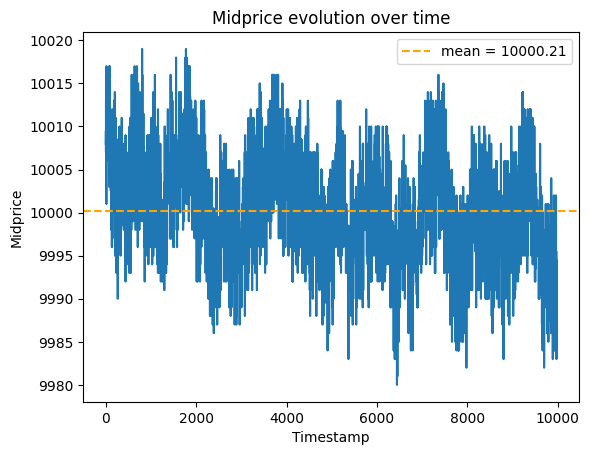

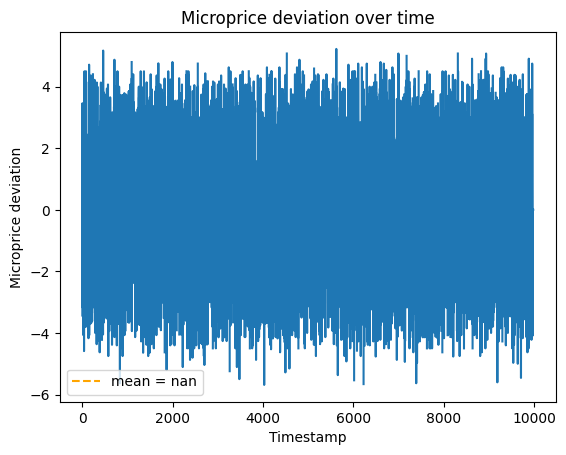

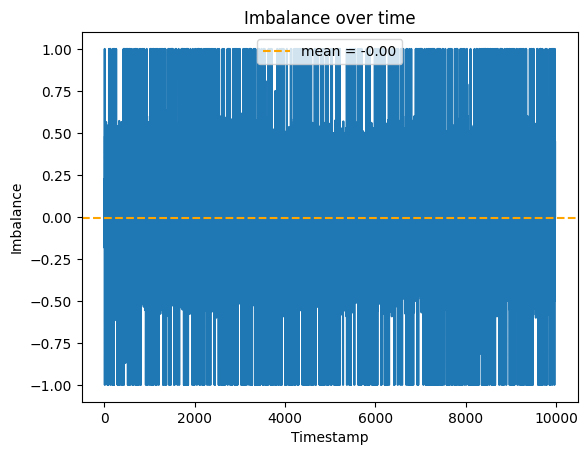

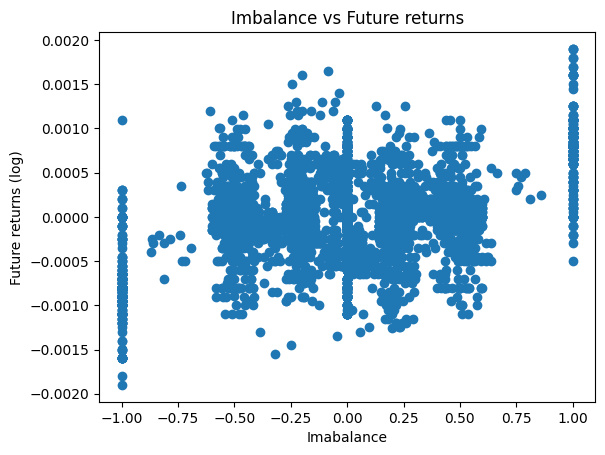

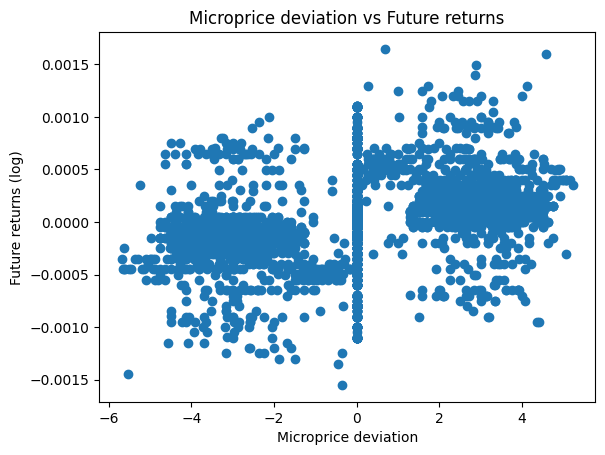

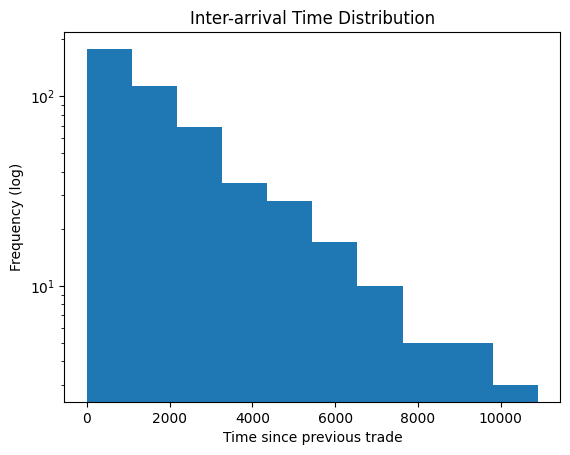

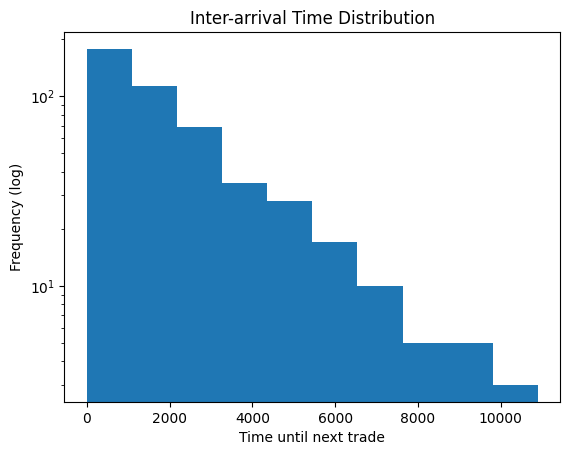

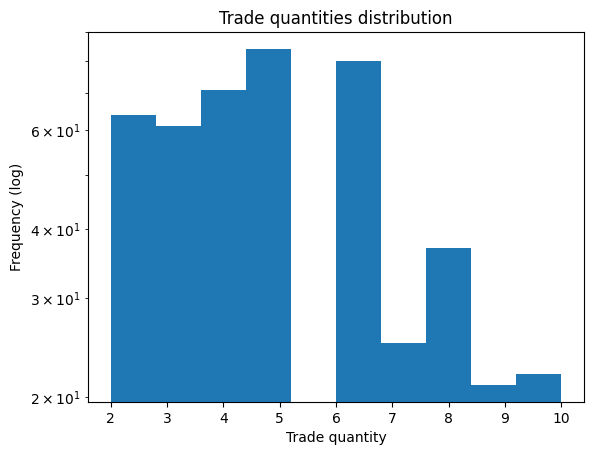

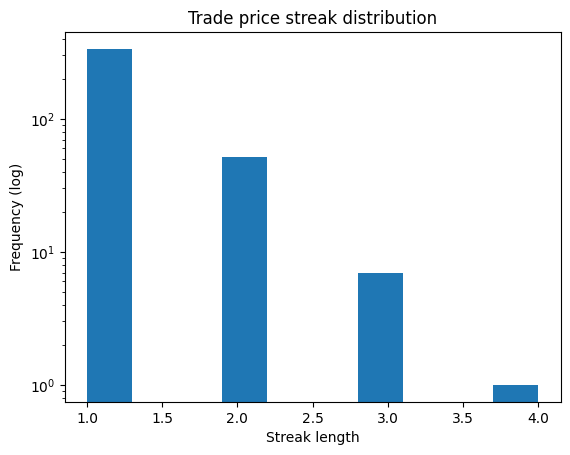

In [42]:
display_plots(plots)

# Mean Reversion Analysis

In [43]:
mean_reversion_results: t.Final[MeanReversionTestResults] = run_mean_reversion_test(
    orderbook_features_data, "mid_price"
)

regression_results: t.Final[SubsampledRegressionResults] = (
    mean_reversion_results.regression_results
)
adf_result: t.Final[ADFResult] = mean_reversion_results.adf_result
hurst_exponents: t.Final[tuple[np.float64, np.float64, np.float64]] = (
    mean_reversion_results.hurst_exponents
)

In [44]:
regression_results.print_summary()


lag_none
midprice (0 skips) is showing signs of mean reversion

lag_5
midprice (5 skips) is showing signs of mean reversion

lag_10
midprice (10 skips) is showing signs of mean reversion


In [45]:
adf_result

ADFResult(feature='mid_price', p_val=0.0015399395339035604)

In [46]:
hurst_exponents

(np.float64(0.1970655531633005),
 np.float64(0.22046885340905195),
 np.float64(0.23090320664089237))